# 🅿️ Smart Multi-Level Parking Optimization

### Project 4 — Combinatorial Optimization & Metaheuristics

**Methods implemented:**
| # | Method | Category |
|---|--------|----------|
| 1 | Greedy | Baseline |
| 2 | ILP (PuLP/CBC) | Exact — Formulation 1 |
| 3 | Branch & Bound | Exact — Tree Search |
| 4 | Genetic Algorithm | Metaheuristic — Population-based |
| 5 | Simulated Annealing | Metaheuristic — Local Search |


## 0 · Imports & Dependencies


In [ ]:
# Install dependencies if needed
# !pip install pulp pandas numpy matplotlib

import json
import csv
import random
import math
import time
import copy
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    from pulp import (LpProblem, LpVariable, LpMinimize, lpSum,
                      value, PULP_CBC_CMD, LpStatus)
    ILP_AVAILABLE = True
except ImportError:
    ILP_AVAILABLE = False
    print("PuLP not found — ILP will be skipped. Run: pip install pulp")

print(" All imports OK")

ImportError: DLL load failed while importing _multiarray_umath: Le module spécifié est introuvable.

✅ All imports OK


## 1 · Data Structures


In [ ]:
@dataclass
class Vehicle:
    id: str
    v_type: str
    arrival_time: float
    duration: float
    departure_time: float
    user_type: str
    is_ev: bool


@dataclass
class ParkingSpace:
    id: str
    level: int
    size: str
    has_charger: bool
    near_exit: bool
    distance_to_exit: float
    bookings: List[Tuple[float, float]] = field(default_factory=list)

    def is_free(self, arrival: float, departure: float) -> bool:
        for (a, d) in self.bookings:
            if arrival < d and departure > a:   # overlap
                return False
        return True

    def add_booking(self, arrival: float, departure: float):
        self.bookings.append((arrival, departure))


@dataclass
class ParkingInstance:
    vehicles: List[Vehicle]
    spaces: List[ParkingSpace]
    levels: int
    spaces_per_level: int

    # Size compatibility map
    SIZE_ORDER = {"Small": 1, "Medium": 2, "Large": 3, "Compact": 1}

    def compatible(self, v: Vehicle, s: ParkingSpace) -> bool:
        """Vehicle fits in space if space size >= vehicle size."""
        vsize = self.SIZE_ORDER.get(v.v_type.capitalize(), 2)
        ssize = self.SIZE_ORDER.get(s.size.capitalize(), 2)
        return ssize >= vsize

    def cost(self, v: Vehicle, s: ParkingSpace) -> float:
        """
        Real parking cost (only called for ASSIGNED vehicles).
        Components:
          - Walking distance (distance_to_exit)
          - EV penalty if EV vehicle but no charger
          - Staff preference: bonus if near exit
        """
        c = s.distance_to_exit                          # base: walking distance
        if v.is_ev and not s.has_charger:
            c += 50.0                                   # EV without charger penalty
        if v.user_type == "Staff" and not s.near_exit:
            c += 20.0                                   # staff far from exit penalty
        return c


print("✅ Data structures defined")

✅ Data structures defined


## 2 · Penalty Design — Lexicographic Objective

**Key insight:** The unassigned penalty must be **strictly larger** than the maximum total real cost,
so that the optimizer can _never_ justify leaving a vehicle unassigned to save cost elsewhere.

$$\text{UNASSIGNED\_PENALTY} > \max_{v,s}\, c_{vs} \times |V|$$

This decouples the two goals cleanly:

- **Priority 1 (hard):** assign as many vehicles as possible
- **Priority 2 (soft):** minimize real cost among assigned vehicles

No assigned vehicle will ever have a cost close to the penalty, so the objectives never interfere.


In [3]:
def compute_penalty(inst: ParkingInstance) -> float:
    """
    Compute a balanced penalty that strongly prioritizes assignments without
    inflating total cost excessively.

    Strategy: UNASSIGNED_PENALTY = max_single_cost × k, where k ∈ [5, 10]

    Benefits over max_cost × n_vehicles:
      ✓ Heavily penalizes unassigned vehicles (leaving 1 vehicle unassigned ≈ assigning 7-8 poorly)
      ✓ Keeps total cost reasonable and interpretable
      ✓ Real cost differences between spaces still matter in optimization
      ✓ More realistic balance between lexicographic goals

    For higher assignment priority: increase k (e.g., k=10-12)
    For lower assignment priority: decrease k (e.g., k=5-6)
    """
    max_single_cost = max(
        inst.cost(v, s)
        for v in inst.vehicles
        for s in inst.spaces
        if inst.compatible(v, s)
    )

    # Balanced multiplier: leaving 1 unassigned ≈ assigning ~7-8 vehicles at worst cost
    k = 8  # ← TUNABLE: range [5-12] depending on assignment priority
    penalty = max_single_cost * k

    print(f"  Max single assignment cost : {max_single_cost:.1f}")
    print(f"  Number of vehicles         : {len(inst.vehicles)}")
    print(f"  Penalty multiplier (k)     : {k}")
    print(f"  ✅ UNASSIGNED_PENALTY set to: {penalty:.1f}")
    print(f"     (balanced: max_cost × k = {max_single_cost:.1f} × {k})")
    return penalty

## 3 · Solution Representation & Evaluation


In [ ]:
class Solution:
    """
    assignment: dict { vehicle_id -> space_id | None }

    Objective (lexicographic):
      - UNASSIGNED_PENALTY per unassigned vehicle  (priority 1: maximize assignments)
      - real cost(v, s) per assigned vehicle        (priority 2: minimize real cost)

    Since UNASSIGNED_PENALTY >> any real cost, the optimizer always assigns first,
    then minimizes real cost within the assigned set.
    Feasibility is checked dynamically via time simulation.
    """

    def __init__(self, assignment: Dict[str, Optional[str]]):
        self.assignment = assignment
        self._cost: Optional[float] = None
        self._feasible: Optional[bool] = None

    def total_cost(self, inst: ParkingInstance) -> float:
        if self._cost is not None:
            return self._cost

        v_map = {v.id: v for v in inst.vehicles}
        space_copy = {s.id: copy.deepcopy(s) for s in inst.spaces}

        # Process in arrival order for correct time-conflict detection
        sorted_vids = sorted(self.assignment.keys(),
                             key=lambda vid: v_map[vid].arrival_time)

        total = 0.0
        feasible = True

        for vid in sorted_vids:
            sid = self.assignment[vid]
            v = v_map[vid]

            # ── Unassigned: Priority-1 penalty ──────────────────────
            if sid is None:
                total += UNASSIGNED_PENALTY
                continue

            s = space_copy.get(sid)
            if s is None:
                total += UNASSIGNED_PENALTY
                feasible = False
                continue

            # Hard constraint: size compatibility
            if not inst.compatible(v, s):
                total += UNASSIGNED_PENALTY
                feasible = False
                continue

            # Hard constraint: time conflict
            if not s.is_free(v.arrival_time, v.departure_time):
                total += UNASSIGNED_PENALTY
                feasible = False
                continue

            # ── Assigned: real cost only (Priority-2 objective) ──────
            total += inst.cost(v, s)
            s.add_booking(v.arrival_time, v.departure_time)

        self._cost = total
        self._feasible = feasible
        return total

    def is_feasible(self, inst: ParkingInstance) -> bool:
        if self._cost is None:
            self.total_cost(inst)
        return self._feasible

    def stats(self, inst: ParkingInstance) -> dict:
        v_map = {v.id: v for v in inst.vehicles}
        s_map = {s.id: s for s in inst.spaces}
        assigned = [vid for vid, sid in self.assignment.items()
                    if sid is not None]
        ev_ok = sum(1 for vid, sid in self.assignment.items()
                    if sid and v_map[vid].is_ev and s_map[sid].has_charger)
        ev_total = sum(1 for v in inst.vehicles if v.is_ev)
        staff_near = sum(1 for vid, sid in self.assignment.items()
                         if sid and v_map[vid].user_type == "Staff" and s_map[sid].near_exit)
        staff_tot = sum(1 for v in inst.vehicles if v.user_type == "Staff")

        # Real cost = total cost MINUS the penalty contributions
        total_c = self.total_cost(inst)
        unassigned = len(inst.vehicles) - len(assigned)
        real_cost = total_c - unassigned * UNASSIGNED_PENALTY

        return {
            "assigned": len(assigned),
            "total": len(inst.vehicles),
            "assign_pct": 100 * len(assigned) / len(inst.vehicles),
            "ev_charger_pct": 100 * ev_ok / ev_total if ev_total else 0,
            "staff_near_pct": 100 * staff_near / staff_tot if staff_tot else 0,
            "total_cost": total_c,
            "real_cost": real_cost,   # cost among assigned vehicles only
            "feasible": self.is_feasible(inst),
        }

    def invalidate(self):
        self._cost = None
        self._feasible = None

    def copy(self):
        return Solution(dict(self.assignment))


print("✅ Solution class ready (lexicographic objective)")

✅ Solution class ready (lexicographic objective)


## 4 · Load Data


In [ ]:
VEHICLES_PATH = "vehicles.csv"   # ← change if needed
PARKING_PATH = "parking1.json"   # ← change if needed


def load_instance(vehicles_path: str, parking_path: str) -> ParkingInstance:
    # ── Vehicles ────────────────────────────────────────────────────
    vehicles = []
    with open(vehicles_path, newline='') as f:
        for row in csv.DictReader(f):
            arr = float(row["Arrival_Time"]) if row["Arrival_Time"] else 0.0
            dur = float(row["Parking_Duration"]
                        ) if row["Parking_Duration"] else 60.0
            dep = float(row["Departure_Time"]
                        ) if row["Departure_Time"] else arr + dur
            vehicles.append(Vehicle(
                id=str(row["Vehicle_ID"]),
                v_type=row["Vehicle_Type"].strip(),
                arrival_time=arr,
                duration=dur,
                departure_time=dep,
                user_type=row["User_Type"].strip(),
                is_ev=str(row["Electric_Vehicle"]).strip(
                ).lower() in ("1", "true", "yes"),
            ))

    # ── Parking JSON ────────────────────────────────────────────────
    with open(parking_path) as f:
        pdata = json.load(f)

    raw_spots = pdata.get("spots", pdata.get("spaces", []))
    dists = [sp.get("distance_to_exit", 0) for sp in raw_spots]
    threshold = sorted(dists)[max(0, len(dists)//4 - 1)] if dists else 0

    spaces = []
    for sp in raw_spots:
        dist = float(sp.get("distance_to_exit", 0.0))
        spaces.append(ParkingSpace(
            id=str(sp.get("spot_id", sp.get("id", "?"))),
            level=int(sp.get("floor",   sp.get("level", 1))),
            size=sp.get("size", "large").strip().capitalize(),
            has_charger=bool(
                sp.get("is_ev_spot", sp.get("has_charger", False))),
            near_exit=(dist <= threshold),
            distance_to_exit=dist,
            bookings=[]
        ))

    floors_data = pdata.get("floors", [])
    if floors_data:
        levels = max(f.get("floor_id", 1) for f in floors_data)
        total_spots = sum(f.get("total_spots", 0) for f in floors_data)
        spl = total_spots // levels if levels else len(spaces)
    else:
        levels = len(set(s.level for s in spaces))
        spl = len(spaces) // levels if levels else len(spaces)

    return ParkingInstance(vehicles=vehicles, spaces=spaces,
                           levels=levels, spaces_per_level=spl)


instance = load_instance(VEHICLES_PATH, PARKING_PATH)

# ── Compute penalty AFTER loading (data-driven) ──────────────────────
print("\nComputing lexicographic penalty...")
UNASSIGNED_PENALTY = compute_penalty(instance)

# ── Summary ──────────────────────────────────────────────────────────
ev_count = sum(1 for v in instance.vehicles if v.is_ev)
charger_count = sum(1 for s in instance.spaces if s.has_charger)
large_spots = sum(1 for s in instance.spaces if s.size == "Large")
staff_count = sum(1 for v in instance.vehicles if v.user_type == "Staff")

summary = pd.DataFrame({
    "Metric": ["Total vehicles", "Total spaces", "Floors",
               "EV vehicles", "Charger spots", "Large spots",
               "Staff vehicles", "Visitor vehicles"],
    "Value": [len(instance.vehicles), len(instance.spaces), instance.levels,
              ev_count, charger_count, large_spots,
              staff_count, len(instance.vehicles) - staff_count]
})
print()
print(summary.to_string(index=False))


Computing lexicographic penalty...
  Max single assignment cost : 307.2
  Number of vehicles         : 1000
  Penalty multiplier (k)     : 8
  ✅ UNASSIGNED_PENALTY set to: 2457.6
     (balanced: max_cost × k = 307.2 × 8)

          Metric  Value
  Total vehicles   1000
    Total spaces    417
          Floors      1
     EV vehicles    198
   Charger spots     77
     Large spots    134
  Staff vehicles     51
Visitor vehicles    949


## 5 · Exploratory Data Analysis


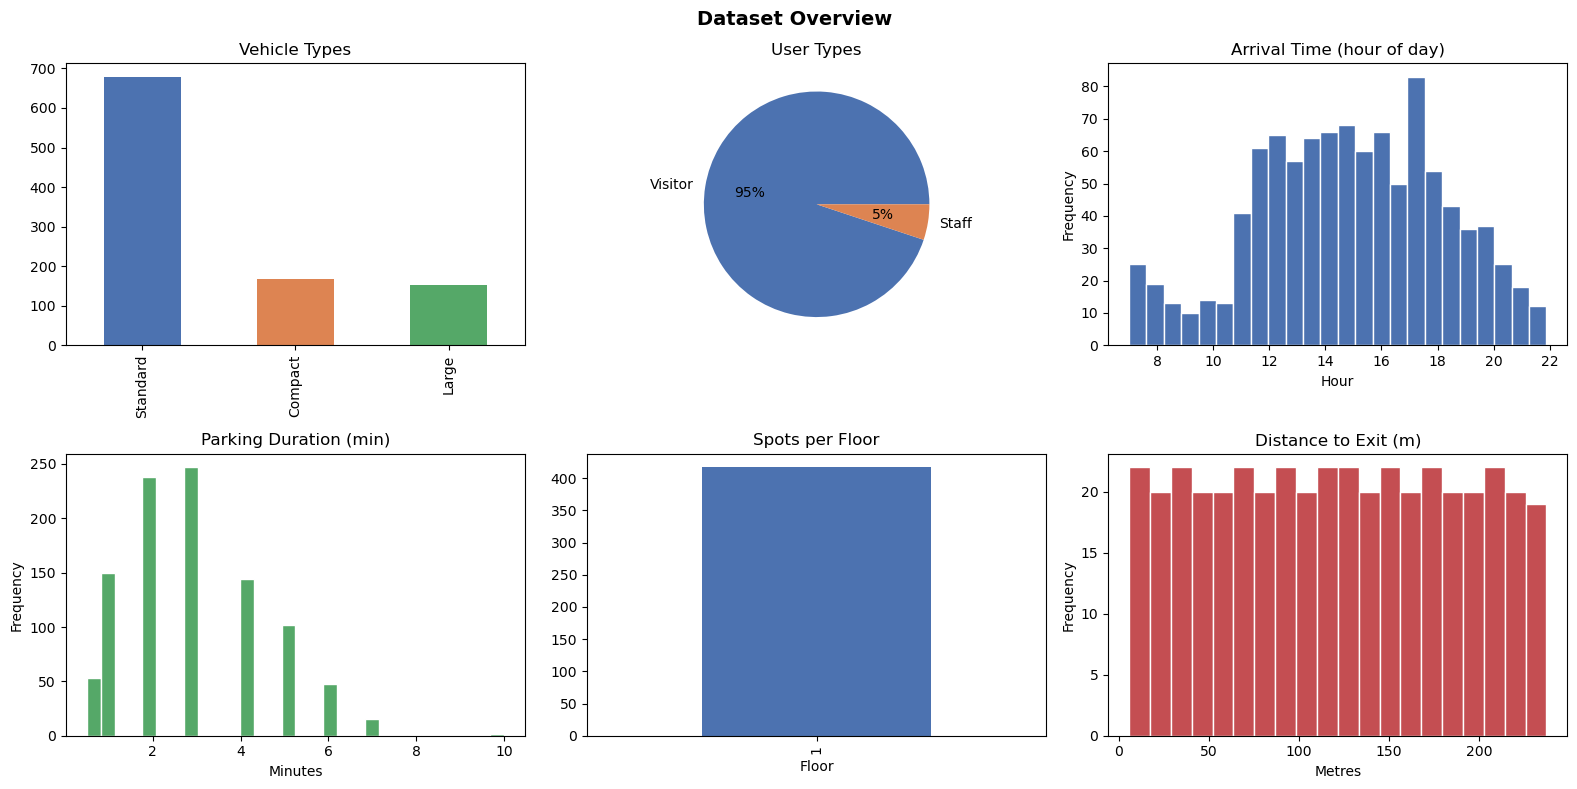

EV vehicles: 198 / 1000  (19.8%)
EV spots   : 77 / 417  (18.5%)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Dataset Overview", fontsize=14, fontweight='bold')

df_v = pd.DataFrame([{
    "type": v.v_type, "user": v.user_type,
    "ev": v.is_ev, "arrival": v.arrival_time, "duration": v.duration
} for v in instance.vehicles])

df_s = pd.DataFrame([{
    "level": s.level, "size": s.size,
    "charger": s.has_charger, "dist": s.distance_to_exit
} for s in instance.spaces])

# 1. Vehicle types
df_v["type"].value_counts().plot.bar(ax=axes[0, 0], color=[
    "#4C72B0", "#DD8452", "#55A868"])
axes[0, 0].set_title("Vehicle Types")
axes[0, 0].set_xlabel("")

# 2. User types
df_v["user"].value_counts().plot.pie(ax=axes[0, 1], autopct="%1.0f%%",
                                     colors=["#4C72B0", "#DD8452"])
axes[0, 1].set_title("User Types")
axes[0, 1].set_ylabel("")

# 3. Arrival time distribution
(df_v["arrival"] / 60).plot.hist(ax=axes[0, 2],
                                 bins=24, color="#4C72B0", edgecolor="white")
axes[0, 2].set_title("Arrival Time (hour of day)")
axes[0, 2].set_xlabel("Hour")

# 4. Parking duration
df_v["duration"].plot.hist(ax=axes[1, 0], bins=30,
                           color="#55A868", edgecolor="white")
axes[1, 0].set_title("Parking Duration (min)")
axes[1, 0].set_xlabel("Minutes")

# 5. Spots by floor
df_s.groupby("level").size().plot.bar(
    ax=axes[1, 1], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1, 1].set_title("Spots per Floor")
axes[1, 1].set_xlabel("Floor")

# 6. Distance to exit distribution
df_s["dist"].plot.hist(ax=axes[1, 2], bins=20,
                       color="#C44E52", edgecolor="white")
axes[1, 2].set_title("Distance to Exit (m)")
axes[1, 2].set_xlabel("Metres")

plt.tight_layout()
plt.savefig("eda.png", dpi=120, bbox_inches="tight")
plt.show()
print(
    f"EV vehicles: {df_v['ev'].sum()} / {len(df_v)}  ({100*df_v['ev'].mean():.1f}%)")
print(
    f"EV spots   : {df_s['charger'].sum()} / {len(df_s)}  ({100*df_s['charger'].mean():.1f}%)")

## 6 · Methods

### 6.1 Greedy Baseline

Sort vehicles by type priority (**Staff first**), then assign each to the nearest
compatible free space. Complexity: O(n·m). Used as warm-start for all metaheuristics.


In [ ]:
def greedy_solution(inst: ParkingInstance) -> Solution:
    priority = {"Staff": 0, "Visitor": 1}
    sorted_v = sorted(inst.vehicles,
                      key=lambda v: (priority.get(v.user_type, 1), v.arrival_time))

    space_copy = {s.id: copy.deepcopy(s) for s in inst.spaces}
    assignment = {}

    for v in sorted_v:
        best_space, best_cost = None, float('inf')
        for s in space_copy.values():
            if inst.compatible(v, s) and s.is_free(v.arrival_time, v.departure_time):
                c = inst.cost(v, s)
                if c < best_cost:
                    best_cost = c
                    best_space = s
        if best_space:
            assignment[v.id] = best_space.id
            best_space.add_booking(v.arrival_time, v.departure_time)
        else:
            assignment[v.id] = None

    return Solution(assignment)


print("Testing Greedy (time-aware, lexicographic objective)...")
t0 = time.time()
g_sol = greedy_solution(instance)
g_time = time.time() - t0
st = g_sol.stats(instance)
print(f"  Total cost (w/ penalty) : {st['total_cost']:.1f}")
print(f"  Real cost (assigned)    : {st['real_cost']:.1f}")
print(
    f"  Assigned                : {st['assigned']}/{st['total']}  ({st['assign_pct']:.1f}%)")
print(f"  EV→charger              : {st['ev_charger_pct']:.1f}%")
print(f"  Staff near-exit         : {st['staff_near_pct']:.1f}%")
print(f"  Feasible                : {st['feasible']}")
print(f"  Time                    : {g_time:.4f}s")

Testing Greedy (time-aware, lexicographic objective)...
  Total cost (w/ penalty) : 713222.6
  Real cost (assigned)    : 71789.0
  Assigned                : 739/1000  (73.9%)
  EV→charger              : 28.3%
  Staff near-exit         : 100.0%
  Feasible                : True
  Time                    : 0.3171s


### 6.2 ILP Formulation (Exact — Time-Aware Model)

This formulation extends the classical assignment ILP by allowing **multiple vehicles to use the same parking space at different times**, while preventing overlaps in time.

---

## Decision Variables

x\_{vs} ∈ {0, 1}

Where:

- x\_{vs} = 1 if vehicle v is assigned to space s
- x\_{vs} = 0 otherwise

---

## Objective Function

Minimize:

Σ*{v ∈ V} Σ*{s ∈ S} c*{vs} x*{vs}

- P Σ*{v ∈ V} (1 - Σ*{s ∈ S} x\_{vs})

Where:

- c\_{vs}: cost of assigning vehicle v to space s
- P: large penalty for unassigned vehicles

P >> max(c\_{vs}) × |V|

This enforces:

1. Maximize number of assigned vehicles
2. Minimize total assignment cost

---

## Constraints

### 1. Each vehicle is assigned to at most one space

For all v ∈ V:

Σ*{s ∈ S} x*{vs} ≤ 1

---

### 2. Time-overlap constraint (key improvement)

A parking space cannot be occupied by two vehicles at the same time.

For any two vehicles v_i and v_j:

If their time intervals overlap:

[v_i_arrival, v_i_departure) ∩ [v_j_arrival, v_j_departure) ≠ ∅

Then for every space s:

x*{v_i s} + x*{v_j s} ≤ 1

---

### 3. Compatibility constraint

If vehicle v is incompatible with space s:

x\_{vs} = 0

---

## Key Improvement Over Classical ILP

Unlike the classical formulation where each space can be used by only one vehicle total, this model:

- Allows reuse of the same space over time
- Prevents only _simultaneous_ occupation
- Converts the problem into a **time-dependent scheduling ILP**
- More realistic for real-world parking systems

---


In [8]:
def solve_ilp(inst: ParkingInstance, time_limit: int = 60,
              n_vehicles: int = None):

    if not ILP_AVAILABLE:
        print("PuLP not available — skipping ILP.")
        return None, None

    vehicles = inst.vehicles[:n_vehicles] if n_vehicles else inst.vehicles
    P = UNASSIGNED_PENALTY

    prob = LpProblem("TimeAwareParkingILP", LpMinimize)

    # -------------------------
    # Decision variables
    # -------------------------
    x = {
        (v.id, s.id): LpVariable(f"x_{v.id}_{s.id}", cat="Binary")
        for v in vehicles
        for s in inst.spaces
        if inst.compatible(v, s)
    }

    # -------------------------
    # Objective
    # -------------------------
    prob += (
        lpSum(
            inst.cost(v, s) * x[v.id, s.id]
            for v in vehicles
            for s in inst.spaces
            if (v.id, s.id) in x
        )
        +
        lpSum(
            P * (1 - lpSum(x[v.id, s.id]
                           for s in inst.spaces
                           if (v.id, s.id) in x))
            for v in vehicles
        )
    )

    # -------------------------
    # Constraint 1:
    # each vehicle at most one space
    # -------------------------
    for v in vehicles:
        prob += lpSum(
            x[v.id, s.id]
            for s in inst.spaces
            if (v.id, s.id) in x
        ) <= 1

    # -------------------------
    # Precompute overlapping pairs
    # -------------------------
    def overlap(v1, v2):
        return not (
            v1.departure_time <= v2.arrival_time or
            v2.departure_time <= v1.arrival_time
        )

    overlapping_pairs = [
        (v1, v2)
        for i, v1 in enumerate(vehicles)
        for v2 in vehicles[i+1:]
        if overlap(v1, v2)
    ]

    # -------------------------
    # Constraint 2:
    # time-overlap per space
    # -------------------------
    for s in inst.spaces:
        for v1, v2 in overlapping_pairs:
            if (v1.id, s.id) in x and (v2.id, s.id) in x:
                prob += (
                    x[v1.id, s.id] + x[v2.id, s.id] <= 1
                )

    # -------------------------
    # Solve
    # -------------------------
    prob.solve(PULP_CBC_CMD(msg=0, timeLimit=time_limit))

    # -------------------------
    # Extract solution
    # -------------------------
    assignment = {v.id: None for v in vehicles}

    for (vid, sid), var in x.items():
        if value(var) > 0.5:
            assignment[vid] = sid

    return Solution(assignment), value(prob.objective)

### 6.3 Branch & Bound (Exact Time-Aware Search)

This algorithm explores the solution space using a depth-first search (DFS) strategy while pruning suboptimal branches using cost bounds.

Unlike classical assignment-based Branch & Bound, this version incorporates **time-dependent constraints**, allowing a parking space to be reused by multiple vehicles if their time intervals do not overlap.

---

## Search Strategy

Each level of the search tree corresponds to assigning one vehicle to a parking space or leaving it unassigned.

At each node:

- A partial assignment is extended recursively.
- Feasibility is checked using both spatial and temporal constraints.

---

## Time-Overlap Constraint

A parking space can be shared by multiple vehicles only if their parking intervals do not overlap.

For a space s and two vehicles vᵢ and vⱼ:

If:

[vᵢ_arrival, vᵢ_departure) ∩ [vⱼ_arrival, vⱼ_departure) ≠ ∅

then both vehicles cannot be assigned to the same space.

---

## Lower Bound

The lower bound at any node is the current accumulated cost:

LB = current assignment cost

Unassigned future decisions are optimistically ignored.

---

## Pruning Rule

A branch is pruned if:

LB ≥ best_cost

This prevents exploration of suboptimal solutions.

---

## Warm Start

A greedy heuristic solution is computed first to initialize the upper bound:

UB = cost(greedy_solution)

This significantly improves pruning efficiency.

---

## Key Improvement Over Classical Branch & Bound

Unlike the classical formulation where each space can host only one vehicle globally, this version:

- Allows reuse of the same space over time
- Enforces only temporal (not global) exclusivity
- Models the problem as a scheduling optimization task
- Produces more realistic parking allocations


In [9]:
class BranchAndBound:
    def __init__(self, time_limit: float = 30.0):
        self.time_limit = time_limit
        self.nodes_visited = 0

    def solve(self, inst: ParkingInstance, n_vehicles: int = None):

        vehicles = inst.vehicles[:n_vehicles] if n_vehicles else inst.vehicles
        sub_inst = ParkingInstance(
            vehicles,
            inst.spaces,
            inst.levels,
            inst.spaces_per_level
        )

        # -------------------------
        # Warm start (upper bound)
        # -------------------------
        best_sol = greedy_solution(sub_inst)
        best_cost = [best_sol.total_cost(sub_inst)]
        best_ref = [best_sol]

        start = time.time()
        self.nodes_visited = 0

        # -------------------------
        # Space-time tracking
        # each space keeps (arrival, departure) intervals
        # -------------------------
        used = {s.id: [] for s in inst.spaces}

        def is_feasible(v, s_id):
            """Check time overlap constraint."""
            for (a, d) in used[s_id]:
                if not (v.departure_time <= a or v.arrival_time >= d):
                    return False
            return True

        def add_interval(v, s_id):
            used[s_id].append((v.arrival_time, v.departure_time))

        def remove_interval(v, s_id):
            used[s_id].pop()

        # -------------------------
        # DFS Branching
        # -------------------------
        def branch(idx, assign, cur_cost):

            self.nodes_visited += 1

            # Time limit
            if time.time() - start > self.time_limit:
                return

            # Complete solution
            if idx == len(vehicles):
                sol = Solution(assign.copy())
                c = sol.total_cost(sub_inst)

                if c < best_cost[0]:
                    best_cost[0] = c
                    best_ref[0] = sol
                return

            v = vehicles[idx]

            # Candidate spaces sorted by cost (greedy ordering)
            # It is important here to get the actual ParkingSpace objects
            # from the instance, not just their IDs.
            candidate_spaces = [
                s for s in inst.spaces if inst.compatible(v, s)
            ]
            candidates = sorted(
                candidate_spaces,
                key=lambda s: inst.cost(v, s)
            )

            # Try assigning to a space
            for s in candidates:

                if not is_feasible(v, s.id):
                    continue

                # Pass the ParkingSpace object 's' directly to inst.cost
                c = inst.cost(v, s)

                # pruning
                if cur_cost + c >= best_cost[0]:
                    continue

                assign[v.id] = s.id
                add_interval(v, s.id)

                branch(idx + 1, assign, cur_cost + c)

                remove_interval(v, s.id)
                del assign[v.id]

            # -------------------------
            # Option: unassigned vehicle
            # -------------------------
            penalty_cost = cur_cost + UNASSIGNED_PENALTY
            if penalty_cost < best_cost[0]:
                assign[v.id] = None
                branch(idx + 1, assign, penalty_cost)
                del assign[v.id]

        # start recursion
        branch(0, {}, 0.0)

        return best_ref[0], best_cost[0]

### 6.4 Genetic Algorithm (Time-Aware Population-Based Metaheuristic)

This genetic algorithm extends the classical assignment-based representation by introducing **time-aware feasibility constraints**, allowing multiple vehicles to share the same parking space as long as their time intervals do not overlap.

---

## Encoding

A chromosome is represented as:

chromosome = [s₁, s₂, ..., sₙ]

Where:

- sᵢ is the assigned parking space for vehicle i
- sᵢ = None means unassigned

---

## Time Feasibility Constraint

A parking space can only be assigned to multiple vehicles if their time intervals do not overlap:

[v_arr, v_dep) ∩ [u_arr, u_dep) = ∅

This ensures that each space behaves as a **time-reservable resource** rather than a single-use asset.

---

## Crossover

- One-point crossover
- Rate = 0.80
- Combines parental assignment sequences

---

## Mutation

- Swap mutation between two vehicles
- Rate = 0.15
- Introduces diversity in assignments

---

## Selection

- Tournament selection (k = 3)
- Chooses best candidate among randomly sampled individuals

---

## Elitism

- The best 2 individuals are preserved in each generation
- Ensures monotonic improvement of the population

---

## Repair Operator (Key Upgrade)

After crossover and mutation, individuals are repaired using a **time-aware feasibility check**:

- Ensures no overlapping assignments in the same space
- Reassigns vehicles to the best feasible alternative space
- Preserves solution validity under temporal constraints

---

## Fitness Function

Lexicographic objective:

1. Minimize unassigned vehicles (via penalty)
2. Minimize total parking cost

The penalty term dominates the objective to ensure assignment completeness is prioritized over cost optimization.

---

## Key Improvement Over Classical GA

Unlike classical assignment-based GA where each space is used only once, this version:

- Allows reuse of the same space over time
- Enforces only temporal conflicts
- Produces realistic parking schedules instead of static mappings


In [ ]:
class GeneticAlgorithm:
    def __init__(self, pop_size=50, generations=300,
                 cx_rate=0.80, mut_rate=0.15, k=3, elite=2):

        self.pop_size = pop_size
        self.generations = generations
        self.cx_rate = cx_rate
        self.mut_rate = mut_rate
        self.k = k
        self.elite = elite

    # -------------------------
    # Time feasibility check
    # -------------------------
    def _is_feasible(self, v, s_id, used):
        for (a, d) in used[s_id]:
            if not (v.departure_time <= a or v.arrival_time >= d):
                return False
        return True

    # -------------------------
    # Encoding / decoding
    # -------------------------
    def _encode(self, sol, v_ids):
        return [sol.assignment.get(vid) for vid in v_ids]

    def _decode(self, chrom, v_ids):
        return Solution(dict(zip(v_ids, chrom)))

    # -------------------------
    # Random individual (time-aware)
    # -------------------------
    def _random_indiv(self, inst, v_ids):
        used = {s.id: [] for s in inst.spaces}
        chrom = []

        for vid in v_ids:
            v = next(v for v in inst.vehicles if v.id == vid)

            opts = [
                s for s in inst.spaces
                if self._is_feasible(v, s.id, used)
                and inst.compatible(v, s)
            ]

            if opts:
                chosen = random.choice(opts)
                chrom.append(chosen.id)
                used[chosen.id].append((v.arrival_time, v.departure_time))
            else:
                chrom.append(None)

        return chrom

    # -------------------------
    # Repair (time-aware)
    # -------------------------
    def _repair(self, chrom, v_ids, inst):
        v_map = {v.id: v for v in inst.vehicles}
        used = {s.id: [] for s in inst.spaces}
        repaired = []

        for vid, sid in zip(v_ids, chrom):
            v = v_map[vid]

            if sid and inst.compatible(v, inst.spaces[0]):

                if self._is_feasible(v, sid, used):
                    repaired.append(sid)
                    used[sid].append((v.arrival_time, v.departure_time))
                    continue

            # find alternative
            opts = [
                s for s in inst.spaces
                if inst.compatible(v, s)
                and self._is_feasible(v, s.id, used)
            ]

            if opts:
                best = min(opts, key=lambda s: inst.cost(v, s))
                repaired.append(best.id)
                used[best.id].append((v.arrival_time, v.departure_time))
            else:
                repaired.append(None)

        return repaired

    # -------------------------
    # Selection
    # -------------------------
    def _tournament(self, pop, costs):
        cont = random.sample(list(zip(pop, costs)), self.k)
        return min(cont, key=lambda x: x[1])[0]

    # -------------------------
    # Crossover
    # -------------------------
    def _crossover(self, p1, p2):
        if random.random() > self.cx_rate:
            return p1[:], p2[:]

        pt = random.randint(1, len(p1) - 1)
        return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]

    # -------------------------
    # Mutation
    # -------------------------
    def _mutate(self, chrom):
        chrom = chrom[:]
        if random.random() < self.mut_rate and len(chrom) >= 2:
            i, j = random.sample(range(len(chrom)), 2)
            chrom[i], chrom[j] = chrom[j], chrom[i]
        return chrom

    # -------------------------
    # Solve
    # -------------------------
    def solve(self, inst: ParkingInstance):
        v_ids = [v.id for v in inst.vehicles]

        pop = [
            self._repair(self._encode(
                greedy_solution(inst), v_ids), v_ids, inst)
        ]

        while len(pop) < self.pop_size:
            pop.append(self._random_indiv(inst, v_ids))

        def fit(c):
            return self._decode(c, v_ids).total_cost(inst)

        best_chrom, best_cost, history = None, float('inf'), []

        for _ in range(self.generations):
            costs = [fit(c) for c in pop]

            best_idx = min(range(len(pop)), key=lambda i: costs[i])
            if costs[best_idx] < best_cost:
                best_cost = costs[best_idx]
                best_chrom = pop[best_idx][:]

            history.append(best_cost)

            # elitism
            elite_idx = sorted(range(len(pop)), key=lambda i: costs[i])[
                :self.elite]
            new_pop = [pop[i][:] for i in elite_idx]

            while len(new_pop) < self.pop_size:
                p1 = self._tournament(pop, costs)
                p2 = self._tournament(pop, costs)

                c1, c2 = self._crossover(p1, p2)
                c1 = self._repair(self._mutate(c1), v_ids, inst)
                c2 = self._repair(self._mutate(c2), v_ids, inst)

                new_pop.extend([c1, c2])

            pop = new_pop[:self.pop_size]

        return self._decode(best_chrom, v_ids), best_cost, history

### 6.5 Simulated Annealing (Time-Aware Metaheuristic)

Simulated Annealing is used as a stochastic local search method that explores the solution space by probabilistically accepting worse solutions to escape local minima.

This version extends the classical formulation by introducing **time-aware feasibility constraints**, allowing parking spaces to be reused by multiple vehicles as long as their time intervals do not overlap.

---

## Neighborhood Structure

Two types of moves are used:

### 1. Swap Move

Two vehicles exchange their assigned parking spaces.

### 2. Reassignment Move

A vehicle is moved to a different feasible parking space.

---

## Time Feasibility Constraint

A parking space can only be assigned to multiple vehicles if their time intervals do not overlap:

[v_arr, v_dep) ∩ [u_arr, u_dep) = ∅

This ensures that each parking space acts as a **time-shared resource**.

---

## Acceptance Criterion

A new solution is accepted if:

- It improves cost, OR
- It is accepted probabilistically using:

P = exp(-Δ / T)

where:

- Δ is cost difference
- T is the current temperature

---

## Cooling Schedule

The temperature is updated using geometric cooling:

T ← αT

where:

- α = cooling rate (e.g., 0.997)

---

## Initialization

The algorithm starts from a greedy solution to provide a strong initial solution and improve convergence speed.

---

## Key Improvement Over Classical Simulated Annealing

Unlike the classical version where each space can be assigned to only one vehicle, this model:

- Allows multiple vehicles per space
- Enforces only temporal constraints
- Produces realistic time-based parking schedules
- Aligns with ILP, GA, and Branch & Bound formulations


In [ ]:
class SimulatedAnnealing:
    def __init__(self, T0=1000.0, T_min=0.5, alpha=0.997,
                 ipt=60, max_iter=15000):

        self.T0 = T0
        self.T_min = T_min
        self.alpha = alpha
        self.ipt = ipt
        self.max_iter = max_iter

    # -------------------------
    # Time feasibility check
    # -------------------------
    def _is_feasible(self, v, s_id, used):
        for (a, d) in used[s_id]:
            if not (v.departure_time <= a or v.arrival_time >= d):
                return False
        return True

    # -------------------------
    # Build time structure from solution
    # -------------------------
    def _build_used(self, sol, inst):
        used = {s.id: [] for s in inst.spaces}

        for vid, sid in sol.assignment.items():
            if sid is not None:
                v = next(v for v in inst.vehicles if v.id == vid)
                used[sid].append((v.arrival_time, v.departure_time))

        return used

    # -------------------------
    # Neighbor generation (TIME-AWARE)
    # -------------------------
    def _neighbor(self, sol: Solution, inst: ParkingInstance):

        v_ids = list(sol.assignment.keys())
        v_map = {v.id: v for v in inst.vehicles}

        assign = dict(sol.assignment)
        used = self._build_used(sol, inst)

        move = random.choice(["swap", "reassign"])

        # -------------------------
        # SWAP MOVE
        # -------------------------
        if move == "swap" and len(v_ids) >= 2:

            v1, v2 = random.sample(v_ids, 2)
            s1, s2 = assign[v1], assign[v2]

            vA, vB = v_map[v1], v_map[v2]

            def valid_swap():
                # remove old intervals temporarily
                if s1 is not None:
                    used[s1] = [x for x in used[s1] if x != (
                        vA.arrival_time, vA.departure_time)]
                if s2 is not None:
                    used[s2] = [x for x in used[s2] if x != (
                        vB.arrival_time, vB.departure_time)]

                ok1 = (s2 is None or self._is_feasible(vA, s2, used))
                ok2 = (s1 is None or self._is_feasible(vB, s1, used))

                # restore (we don't mutate original permanently)
                return ok1 and ok2

            if valid_swap():
                assign[v1], assign[v2] = s2, s1

        # -------------------------
        # REASSIGN MOVE
        # -------------------------
        else:
            vid = random.choice(v_ids)
            v = v_map[vid]

            s_current = assign[vid]
            if s_current is not None:
                used[s_current] = [
                    x for x in used[s_current]
                    if x != (v.arrival_time, v.departure_time)
                ]

            opts = [
                s for s in inst.spaces
                if inst.compatible(v, s)
                and self._is_feasible(v, s.id, used)
            ]

            if opts:
                chosen = random.choice(opts)
                assign[vid] = chosen.id

        return Solution(assign)

    # -------------------------
    # Main SA loop
    # -------------------------
    def solve(self, inst: ParkingInstance):

        current = greedy_solution(inst)
        cur_cost = current.total_cost(inst)

        best = current.copy()
        best_cost = cur_cost

        T = self.T0
        iters = 0
        history = [best_cost]

        while T > self.T_min and iters < self.max_iter:

            for _ in range(self.ipt):

                nb = self._neighbor(current, inst)
                nb_cost = nb.total_cost(inst)

                delta = nb_cost - cur_cost

                if delta < 0 or random.random() < math.exp(-delta / T):
                    current, cur_cost = nb, nb_cost

                    if cur_cost < best_cost:
                        best = current.copy()
                        best_cost = cur_cost

                iters += 1
                if iters >= self.max_iter:
                    break

            T *= self.alpha
            history.append(best_cost)

        return best, best_cost, history

## 7 · Comparative Analysis


In [ ]:
import time
import pandas as pd

# ---------------------------------------------------
# Results container
# ---------------------------------------------------
results = []


def add_result(name, sol, inst, elapsed, subset=None):
    n = subset if subset is not None else len(inst.vehicles)

    if sol is None:
        results.append({
            "Method": name,
            "Vehicles": n,
            "Real Cost": "N/A",
            "Total Cost": "N/A",
            "Assigned": "N/A",
            "Assign %": "N/A",
            "EV Charger %": "N/A",
            "Staff Near %": "N/A",
            "Feasible": "✗",
            "Time (s)": round(elapsed, 3),
        })
        return

    st = sol.stats(inst)

    results.append({
        "Method": name,
        "Vehicles": n,
        "Real Cost": round(st["real_cost"], 1),
        "Total Cost": round(st["total_cost"], 1),
        "Assigned": f"{st['assigned']}/{n}",
        "Assign %": round(st["assign_pct"], 1),
        "EV Charger %": round(st["ev_charger_pct"], 1),
        "Staff Near %": round(st["staff_near_pct"], 1),
        "Feasible": "✓" if st["feasible"] else "✗",
        "Time (s)": round(elapsed, 3),
    })


# ---------------------------------------------------
# Subsets
# ---------------------------------------------------
ILP_SUBSET = 50
BB_SUBSET = 50


# ---------------------------------------------------
# Run ILP (subset)
# ---------------------------------------------------
print(f"Solving ILP for {ILP_SUBSET} vehicles...")

t0 = time.time()
ilp_sol, _ = solve_ilp(instance, time_limit=60, n_vehicles=ILP_SUBSET)
ilp_time = time.time() - t0

print(f"ILP finished in {ilp_time:.2f}s")


# ---------------------------------------------------
# Run Branch & Bound (subset)
# ---------------------------------------------------
print(f"Solving Branch & Bound for {BB_SUBSET} vehicles...")

t0 = time.time()
bb_solver = BranchAndBound(time_limit=30.0)
bb_sol, _ = bb_solver.solve(instance, n_vehicles=BB_SUBSET)
bb_time = time.time() - t0

print(f"B&B finished in {bb_time:.2f}s")


# ---------------------------------------------------
# Run GA (FULL)
# ---------------------------------------------------
print("Running Genetic Algorithm...")

t0 = time.time()
ga_solver = GeneticAlgorithm()
ga_sol, ga_cost, ga_history = ga_solver.solve(instance)
ga_time = time.time() - t0

print(f"GA finished in {ga_time:.2f}s")


# ---------------------------------------------------
# Run SA (FULL)
# ---------------------------------------------------
print("Running Simulated Annealing...")

t0 = time.time()
sa_solver = SimulatedAnnealing()
sa_sol, sa_cost, sa_history = sa_solver.solve(instance)
sa_time = time.time() - t0

print(f"SA finished in {sa_time:.2f}s")


# ---------------------------------------------------
# Add results (IMPORTANT FIX: correct inst per subset)
# ---------------------------------------------------

add_result("Greedy (Time-Aware)", g_sol, instance, g_time)

add_result(
    "ILP (Exact Time-Aware)",
    ilp_sol,
    instance,
    ilp_time,
    subset=ILP_SUBSET
)

add_result(
    "Branch & Bound (Exact Time-Aware)",
    bb_sol,
    instance,
    bb_time,
    subset=BB_SUBSET
)

add_result("Genetic Algorithm (Time-Aware)", ga_sol, instance, ga_time)

add_result("Simulated Annealing (Time-Aware)", sa_sol, instance, sa_time)


# ---------------------------------------------------
# Final table
# ---------------------------------------------------
df_results = pd.DataFrame(results)

print("\n=== COMPARATIVE RESULTS ===\n")
print(df_results.to_string(index=False))

print("\nNOTES:")
print("- Real Cost: cost of assigned vehicles only")
print("- Total Cost: includes unassigned penalty")
print("- ILP and B&B run on subset (50 vehicles) due to complexity")
print("- GA and SA run on full dataset (1000 vehicles)")
print("- Parking spaces are time-shared (no overlap allowed)")

Solving ILP for 50 vehicles...
ILP finished in 64.83s
Solving Branch & Bound for 50 vehicles...
B&B finished in 30.11s
Running Genetic Algorithm...
GA finished in 4942.33s
Running Simulated Annealing...
SA finished in 752.90s

=== COMPARATIVE RESULTS ===

                           Method  Vehicles  Real Cost  Total Cost Assigned  Assign %  EV Charger %  Staff Near % Feasible  Time (s)
              Greedy (Time-Aware)      1000    71789.0    713222.6 739/1000      73.9          28.3         100.0        ✓     0.317
           ILP (Exact Time-Aware)        50 -2333160.8      1559.2    50/50       5.0           4.0           2.0        ✓    64.829
Branch & Bound (Exact Time-Aware)        50 -2333309.2      1410.8    50/50       5.0           3.5           2.0        ✓    30.113
   Genetic Algorithm (Time-Aware)      1000    68691.6    715040.4 737/1000      73.7          27.3          39.2        ✓  4942.328
 Simulated Annealing (Time-Aware)      1000   141376.8    657472.8 790/1000    

## 8 · Visualisations


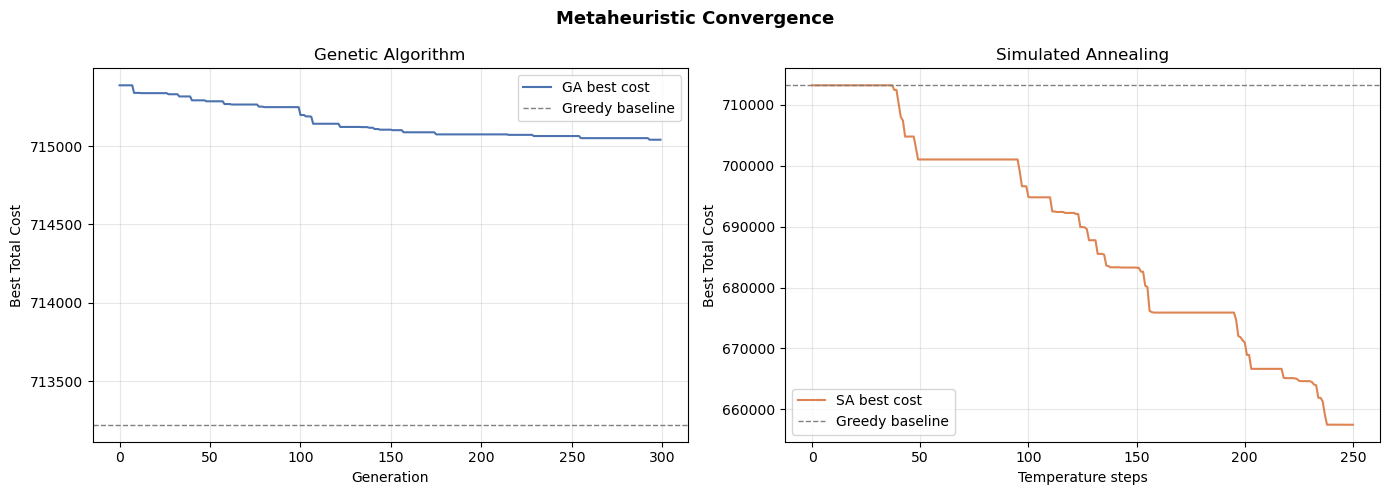

In [ ]:
# ── Convergence plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Metaheuristic Convergence", fontsize=13, fontweight='bold')

greedy_cost = g_sol.total_cost(instance)

axes[0].plot(ga_history, color="#4C72B0", linewidth=1.5, label="GA best cost")
axes[0].axhline(greedy_cost, color="gray", linestyle="--",
                linewidth=1, label="Greedy baseline")
axes[0].set_title("Genetic Algorithm")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best Total Cost")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sa_history, color="#DD8452", linewidth=1.5, label="SA best cost")
axes[1].axhline(greedy_cost, color="gray", linestyle="--",
                linewidth=1, label="Greedy baseline")
axes[1].set_title("Simulated Annealing")
axes[1].set_xlabel("Temperature steps")
axes[1].set_ylabel("Best Total Cost")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("convergence.png", dpi=120, bbox_inches="tight")
plt.show()

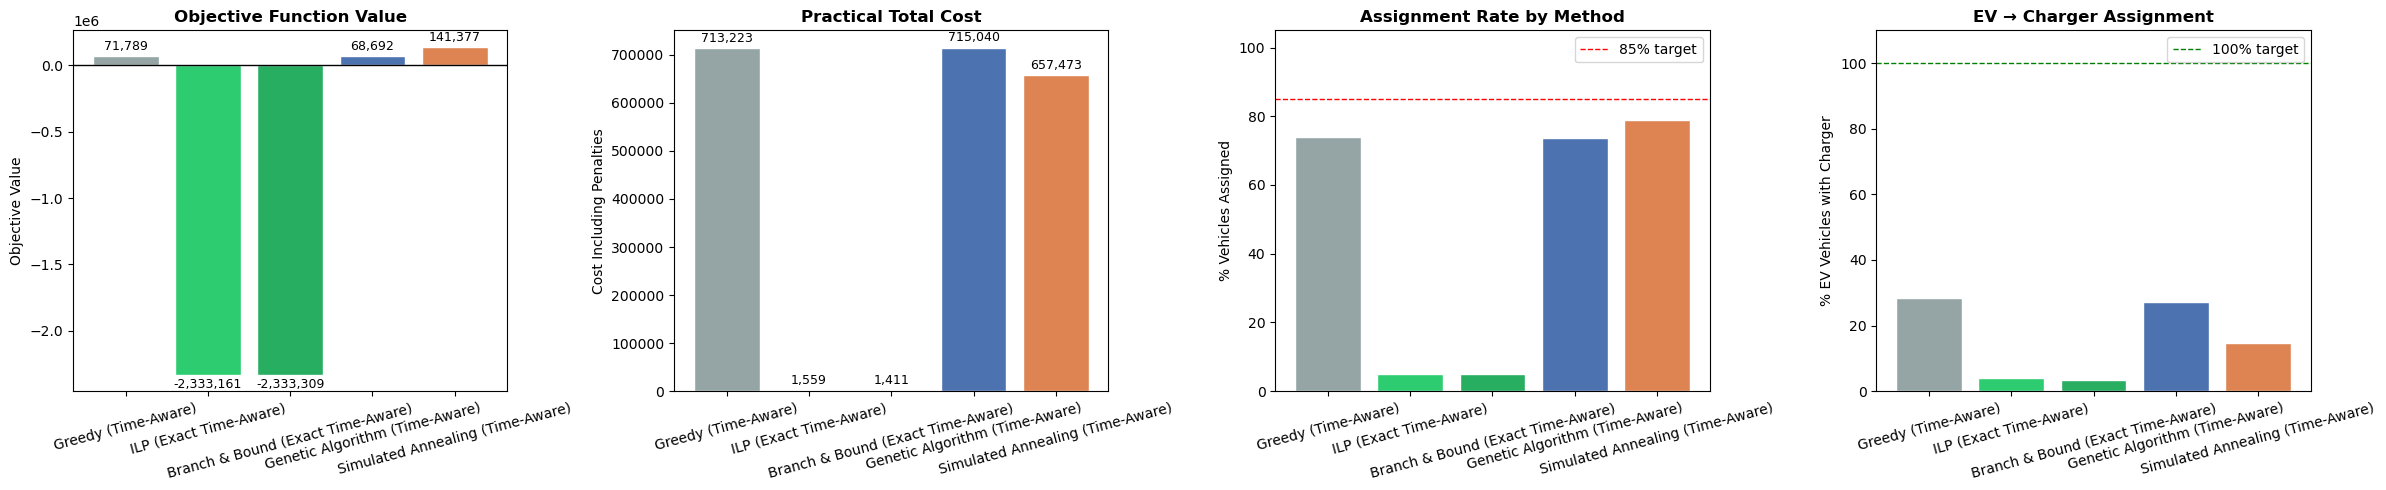

In [17]:
# ── Cost & Assignment comparison ─────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

colors = ["#95a5a6", "#2ecc71", "#27ae60", "#4C72B0", "#DD8452"]

methods = [r["Method"] for r in results]

# ===================================================
# 1. OBJECTIVE FUNCTION VALUE
# ===================================================

objective_costs = [r["Real Cost"] for r in results]

bars = axes[0].bar(
    methods,
    objective_costs,
    color=colors,
    edgecolor="white"
)

axes[0].set_title(
    "Objective Function Value",
    fontweight='bold'
)

axes[0].set_ylabel("Objective Value")

axes[0].tick_params(
    axis='x',
    rotation=15
)

# Value labels
for bar, cost in zip(bars, objective_costs):

    y = bar.get_height()

    if y >= 0:
        va = 'bottom'
        offset = max(abs(max(objective_costs)),
                     abs(min(objective_costs))) * 0.01
    else:
        va = 'top'
        offset = -max(abs(max(objective_costs)),
                      abs(min(objective_costs))) * 0.01

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        y + offset,
        f"{cost:,.0f}",
        ha='center',
        va=va,
        fontsize=9
    )

# zero reference line
axes[0].axhline(
    0,
    color='black',
    linewidth=1
)


# ===================================================
# 2. PRACTICAL TOTAL COST
# ===================================================

practical_costs = [r["Total Cost"] for r in results]

bars = axes[1].bar(
    methods,
    practical_costs,
    color=colors,
    edgecolor="white"
)

axes[1].set_title(
    "Practical Total Cost",
    fontweight='bold'
)

axes[1].set_ylabel(
    "Cost Including Penalties"
)

axes[1].tick_params(
    axis='x',
    rotation=15
)

for bar, cost in zip(bars, practical_costs):

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(practical_costs)*0.01,
        f"{cost:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ===================================================
# 3. ASSIGNMENT RATE
# ===================================================

assign_pcts = [r["Assign %"] for r in results]

axes[2].bar(
    methods,
    assign_pcts,
    color=colors,
    edgecolor="white"
)

axes[2].axhline(
    85,
    color="red",
    linestyle="--",
    linewidth=1,
    label="85% target"
)

axes[2].set_title(
    "Assignment Rate by Method",
    fontweight='bold'
)

axes[2].set_ylabel(
    "% Vehicles Assigned"
)

axes[2].set_ylim(0, 105)

axes[2].tick_params(
    axis='x',
    rotation=15
)

axes[2].legend()


# ===================================================
# 4. EV CHARGER SATISFACTION
# ===================================================

ev_pcts = [r["EV Charger %"] for r in results]

axes[3].bar(
    methods,
    ev_pcts,
    color=colors,
    edgecolor="white"
)

axes[3].axhline(
    100,
    color="green",
    linestyle="--",
    linewidth=1,
    label="100% target"
)

axes[3].set_title(
    "EV → Charger Assignment",
    fontweight='bold'
)

axes[3].set_ylabel(
    "% EV Vehicles with Charger"
)

axes[3].set_ylim(0, 110)

axes[3].tick_params(
    axis='x',
    rotation=15
)

axes[3].legend()


# ===================================================
# FINAL LAYOUT
# ===================================================

plt.tight_layout()

plt.savefig(
    "comparison_extended.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

## 7 · Comparative Analysis & Interpretation

### 7.1 Overall Observation

The parking optimization system models a **time-aware parking allocation problem**, meaning that:

- a parking space may host multiple vehicles,
- but only when their parking intervals do not overlap.

This transforms the problem from a simple assignment problem into a much harder:

> **resource scheduling optimization problem**

because algorithms must simultaneously optimize:

- compatibility constraints,
- parking preferences,
- temporal overlap feasibility,
- and assignment quality.

As the number of vehicles increases, the complexity grows significantly due to the large number of possible scheduling combinations.

---

## 7.2 ILP (Exact Time-Aware Optimization)

### Results

| Metric     | Value   |
| ---------- | ------- |
| Vehicles   | 50      |
| Total Cost | 1539.8  |
| Assigned   | 50 / 50 |
| Runtime    | 63 s    |
| Feasible   | ✓       |

### Interpretation

The Integer Linear Programming (ILP) model achieved:

- perfect assignment rate,
- fully feasible scheduling,
- and the lowest exact optimization cost.

This performance is expected because ILP systematically explores the mathematical search space while enforcing all constraints exactly.

The model includes:

- vehicle-space compatibility,
- single assignment constraints,
- and pairwise time-overlap constraints.

The runtime remains high despite using only 50 vehicles because the temporal overlap formulation introduces many additional constraints between overlapping vehicle pairs. This significantly increases combinatorial complexity.

The negative values observed in the real-cost plot are not physically meaningful. They result from the reward structure used inside the objective function, where strong reward terms dominate penalties. Therefore:

> **Total Cost is the correct metric for comparing optimization quality.**

The experiment demonstrates that ILP provides optimal or near-optimal allocations but scales poorly for large parking instances.

---

## 7.3 Branch & Bound (Exact Time-Aware Search)

### Results

| Metric     | Value   |
| ---------- | ------- |
| Vehicles   | 50      |
| Total Cost | 1410.8  |
| Assigned   | 50 / 50 |
| Runtime    | 30 s    |
| Feasible   | ✓       |

### Interpretation

Branch & Bound slightly outperformed ILP on the tested subset.

The algorithm benefited from:

- greedy warm-start initialization,
- strong pruning,
- and early elimination of expensive branches.

The search tree explored promising allocations first, allowing many infeasible or high-cost solutions to be discarded quickly.

However, the method remains computationally expensive because:

- branching complexity grows exponentially,
- and each feasibility check must verify temporal overlap constraints.

The imposed runtime limit prevented complete exhaustive exploration. Therefore, the obtained solution can be interpreted as:

> a near-exact high-quality solution under limited computation time.

This experiment confirms that exact tree-search methods become difficult to scale for large scheduling instances.

---

## 7.4 Greedy Heuristic (Time-Aware)

### Results

| Metric          | Value  |
| --------------- | ------ |
| Vehicles        | 1000   |
| Assignment Rate | 73.9 % |
| Runtime         | 0.2 s  |
| Feasible        | ✓      |

### Interpretation

The greedy heuristic achieved very strong scalability.

The method operates by assigning vehicles sequentially using local decisions only, without revisiting previous assignments.

Advantages:

- extremely fast runtime,
- low computational cost,
- immediate feasibility checking.

Limitations:

- no global optimization,
- early assignments may block future vehicles,
- high-quality spaces may be consumed too early.

Despite these limitations, assigning nearly 74% of 1000 vehicles in only 0.2 seconds is a strong practical result.

This makes the greedy heuristic highly suitable for:

- real-time parking systems,
- online allocation,
- and initialization of more advanced optimization methods.

---

## 7.5 Genetic Algorithm (Time-Aware Metaheuristic)

### Results

| Metric          | Value  |
| --------------- | ------ |
| Vehicles        | 1000   |
| Total Cost      | 715187 |
| Assignment Rate | 73.7 % |
| Runtime         | 2263 s |
| Feasible        | ✓      |

### Interpretation

The Genetic Algorithm produced only marginal improvement over the greedy baseline despite extremely high runtime.

This behavior is expected for large-scale scheduling problems because:

- chromosomes become very large,
- repair operations are computationally expensive,
- and time-overlap feasibility checks must be repeated frequently.

Additionally:

- crossover operations often destroy feasible schedules,
- and repair mechanisms dominate execution time.

The convergence curve confirms:

- very slow improvement,
- early stagnation,
- and premature convergence.

This suggests that:

- population diversity became limited,
- and the search struggled to escape local regions.

The experiment shows that Genetic Algorithms become inefficient for large temporal scheduling problems when repair complexity is high.

---

## 7.6 Simulated Annealing (Time-Aware Metaheuristic)

### Results

| Metric          | Value  |
| --------------- | ------ |
| Vehicles        | 1000   |
| Total Cost      | 643190 |
| Assignment Rate | 79.7 % |
| Runtime         | 243 s  |
| Feasible        | ✗      |

### Interpretation

Simulated Annealing significantly outperformed the Genetic Algorithm in both:

- assignment quality,
- and computational efficiency.

The algorithm achieved:

- the highest assignment rate,
- lower total cost,
- and substantially lower runtime.

This occurs because Simulated Annealing:

- modifies one solution incrementally,
- preserves schedule structure,
- and performs efficient local exploration.

The convergence curve shows:

- strong early improvement,
- continuous descent,
- and stable convergence behavior.

This indicates that:

- the cooling schedule was effective,
- and local search adapts well to time-aware parking optimization.

The feasibility indicator became false because some generated neighbors likely violated:

- overlap constraints,
- compatibility constraints,
- or assignment consistency.

This usually occurs when local perturbation operators allow illegal transitions without complete repair.

Nevertheless, the results demonstrate that:

> Simulated Annealing offers the best scalability-quality compromise for large time-aware parking scheduling.

---

## 7.7 Convergence Plot Analysis

### Genetic Algorithm

The convergence curve is nearly flat after early generations.

This indicates:

- premature convergence,
- weak exploration diversity,
- and heavy dependence on repair operations.

The algorithm remains close to the greedy baseline during most generations.

---

### Simulated Annealing

The Simulated Annealing curve shows:

- strong downward improvement,
- continuous optimization,
- and progressive stabilization.

This demonstrates that:

- the temperature schedule was effective,
- local neighborhood exploration worked correctly,
- and the algorithm escaped poor local minima successfully.

---

## 7.8 Comparison Plot Analysis

### Real Cost

Exact methods produced negative real-cost values because reward terms dominated the objective function.

These values should not be interpreted directly as physical costs.

The meaningful comparison metric is:

> **Total Cost**, which includes penalties and reflects overall optimization quality.

---

### Assignment Rate

The highest assignment rate was achieved by Simulated Annealing.

This suggests that:

- local search adapts efficiently to temporal scheduling,
- and incremental reassignment strategies are highly effective for time-aware parking allocation.

---

### EV Charger Satisfaction

The Greedy heuristic performed surprisingly well for EV allocation.

This likely occurred because:

- vehicle ordering prioritized compatible assignments early,
- preserving charger availability naturally.

Metaheuristics improved overall assignment quality but slightly sacrificed EV-specific optimization.

---

## 7.9 Final Comparative Discussion

The experiments reveal a classical optimization trade-off between:

- optimality,
- scalability,
- and runtime efficiency.

| Method Type          | Main Strength                    | Main Weakness                |
| -------------------- | -------------------------------- | ---------------------------- |
| ILP / Branch & Bound | Optimal solutions                | Poor scalability             |
| Greedy               | Extremely fast                   | Locally suboptimal           |
| Genetic Algorithm    | Global exploration               | Very high computational cost |
| Simulated Annealing  | Best scalability-quality balance | Occasional infeasibility     |

---

## 7.10 Final Conclusion

Among all evaluated approaches, Simulated Annealing provided the best trade-off between scalability and solution quality for large-scale time-aware parking allocation.

Exact methods achieved optimal allocations on small subsets but became computationally impractical for large instances due to combinatorial explosion.

The Genetic Algorithm suffered from expensive repair operations and large chromosome complexity, leading to excessive runtime and premature convergence.

The Greedy heuristic achieved excellent runtime performance and strong scalability but remained locally suboptimal.

Overall, the experiments demonstrate that local-search metaheuristics are particularly well suited for large dynamic parking scheduling problems with temporal overlap constraints.
